# Real data results
This jupyter notebook generates the RSM variability results with real data. It generates the corresponding figures in the paper *Stimulus symmetries can confound representational similarity analyses*.

# Load a sample image
This is a digit from the Japanese characters (KMNIST) dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
from PIL import Image
from utils import *
import copy

plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['font.size'] = 14

# Load the reference image
ref_img = np.load('data/ref_kmnist_img.npz')['ref_img']

# Note: The baseline image is a digit Kuzushiji-49 training dataset, and was accessed from https://github.com/rois-codh/kmnist,895
# where it is available under a CC BY-SA 4.0 License.
# To load it from the original data, download the data from the above repository, and place the .npz files in the 'data/kmnist-master/' folder, and uncomment the followign:
# data = np.load('data/kmnist-master/k49-train-imgs.npz')
# # Access the data (replace 'arr_0' with the actual key name)
# images = data['arr_0']
# ref_img = images[1,:,:]  # Pick the image

print(f"Shape: {ref_img.shape}")

Shape: (28, 28)


# Generate rotated versions of the baseline image

imgs shape: (180, 28, 28, 1)


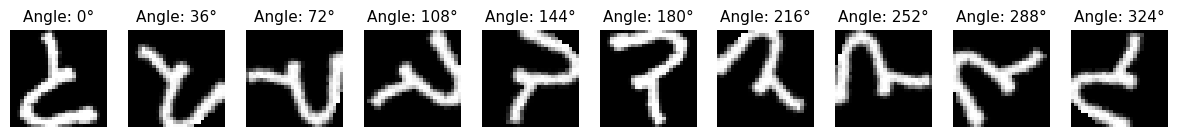

In [2]:
N = 180 # Number of rotations (e.g., 180 for every 2 degrees)

fig_folder = 'output'
save_figures = True
if save_figures and not os.path.exists(fig_folder):
    os.makedirs(fig_folder)

Nx, Ny, numchannels = ref_img.shape[0], ref_img.shape[1], 1
# --- ROTATION ANGLES ---
angles = np.linspace(0, 360, num=N+1, endpoint=True)[:-1]  # Exclude 360deg

# --- GENERATE ROTATED IMAGES ---
imgs = np.zeros((N, Nx, Ny, 1), dtype=np.float32)

for idx, angle in enumerate(angles):
    pil_img = Image.fromarray(ref_img)
    # Rotate around center, keep image size and pad as needed
    rotated = pil_img.rotate(angle, resample=Image.BILINEAR)
    img_arr = np.array(rotated, dtype=np.float32) / 255.0  # Normalize to [0,1]
    imgs[idx, :, :, 0] = img_arr

print("imgs shape:", imgs.shape)  # (N, 28, 28, 1)



import matplotlib.pyplot as plt

# --- SHOW SOME SAMPLES FROM THE ROTATED IMAGES ---
num_show = min(10, N)  # Number of images to show
plt.figure(figsize=(12, 2))

for i in range(num_show):
    # choose images evenly spaced
    idx = i * (N // num_show)
    plt.subplot(1, num_show, i+1)
    plt.imshow(imgs[idx, :, :, 0], cmap='gray')
    plt.title(f'Angle: {angles[idx]:.0f}°', fontsize=11)
    plt.axis('off')
plt.tight_layout()
#plt.savefig(fig_folder + '/rotated_images_sample_japanese.svg', dpi=300)

# Baseline neural network

In [3]:
LOAD_BASE_MODEL = True # Load existing model if True, otherwise train new ones

# Model parameters (KMNIST)
epochs = 500
hidden_dim = 32
l1_weight_reg = 0.0
l2_weight_reg = 5e-3
l1_activation_reg = 2e-5
l2_activation_reg = 0
use_bias = True
batch_size = 24
learning_rate = 0.01
synnoise = 0.02
visualize_results_flag = True
savefigfile = os.path.join(fig_folder,'autoencoder_japanese32.svg')

if LOAD_BASE_MODEL:
    params = {'hidden_dim': hidden_dim, 'epochs': epochs, 'batch_size': batch_size, 'learning_rate': learning_rate, 'use_bias': use_bias, 'l1_weight_reg': l1_weight_reg, 'l2_weight_reg': l2_weight_reg, 'l1_activation_reg': l1_activation_reg, 'l2_activation_reg': l2_activation_reg,'visualize_results_flag': visualize_results_flag, 'synnoise': synnoise, 'savefigfile':savefigfile}
    modelbase = TwoLayerAutoencoder(input_dim=imgs.shape[1]*imgs.shape[2], hidden_dim=params['hidden_dim'], use_bias=params['use_bias'])
    modelfile = 'models/kmnist1rot_base_plot32.pt'
    modelbase.load_state_dict(torch.load(modelfile))
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    scaler.fit(imgs.reshape(imgs.shape[0], -1))
else:
    # Fresh run
    params = {'hidden_dim': hidden_dim, 'epochs': epochs, 'batch_size': batch_size, 'learning_rate': learning_rate, 'use_bias': use_bias, 'l1_weight_reg': l1_weight_reg, 'l2_weight_reg': l2_weight_reg, 'l1_activation_reg': l1_activation_reg, 'l2_activation_reg': l2_activation_reg,'visualize_results_flag': visualize_results_flag, 'synnoise': synnoise, 'savefigfile':savefigfile}
    model, hidden_reps, phases, colors, scaler = run_model(model = None, imgs=np.roll(imgs, shift=0, axis=0), params=params)
    hidden_activations, angles = compute_receptive_fields_from_imgs(model, imgs, scaler, scaler_type='minmax')
    modelbase = copy.deepcopy(model)

    # Optional: save the base model
    # modelfile = 'models/kmnist1rot_base_plot32i.pt'
    # torch.save(modelbase.state_dict(), modelfile)

# Plot RFs of the baseline model

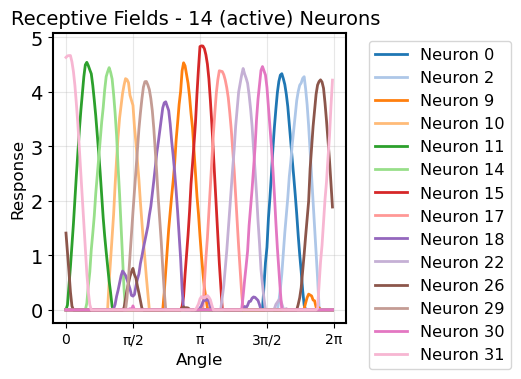

In [4]:
hidden_activations, angles = compute_receptive_fields_from_imgs(modelbase, imgs, scaler, scaler_type='minmax')
#savefigfile = os.path.join(fig_folder,'autoencoder_japanese32_rfs.svg')
savefigfile = None
idx_active_neurons = np.where(np.max(hidden_activations,axis=0)>1)[0]
plot_neuron_rfs_simple(hidden_activations, angles, neuron_indices=list(idx_active_neurons), figsize=(5.5, 4), savefigfile=savefigfile)

# Visualize the baseline model

Saved figure to output/autoencoder_japanese32_2.svg


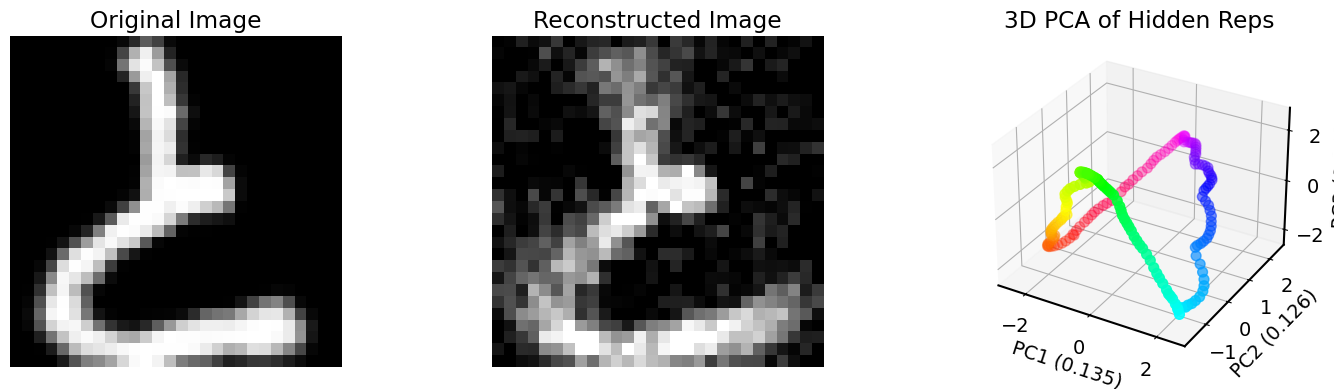

In [5]:
savefigfile = os.path.join(fig_folder,'autoencoder_japanese32_2.svg')
#savefigfile = None
hidden_reps2, phases2, colors2 = visualize_autoencoder_results(
    model=modelbase,
    imgs=imgs,
    scaler=None,
    scaler_type=None,   # or the string you used
    device='cuda' if torch.cuda.is_available() else 'cpu',
    savefigfile=savefigfile
)


# Analyze RSM variability for multiple realizations of the model

# Setup and (optionally) run new trainings

In [ ]:
LOAD_MODELS = True # If True, loads the models from the folder, otherwise trains new models for multiple runs and saves them. Set to False if you want to train new models, and set to True if you want to load existing models and compute results (e.g., for plotting).
#numruns = 1000
numruns = 50 # Set to 50 for quick testing, but for the paper we used numruns = 1000
models_folder = 'models/kmnist1rot_exp32'

import os
if not os.path.exists(models_folder):
    os.makedirs(models_folder)
    # save params to the same folder
import json
with open(os.path.join(models_folder, 'params.json'), 'w') as f:
    json.dump(params, f)


if not LOAD_MODELS: # Runs training for multiple runs and saves the models
    runs = range(numruns)
    for run in np.arange(0, numruns):
        params['visualize_results_flag'] = False
        model, hidden_reps, phases, colors, scaler = run_model(model = None, imgs=imgs, params=params)
        modelfile = os.path.join(models_folder, f'model_run{run}.pth')
        torch.save(model.state_dict(), modelfile)

# Extract data for runs with a given number of RFs

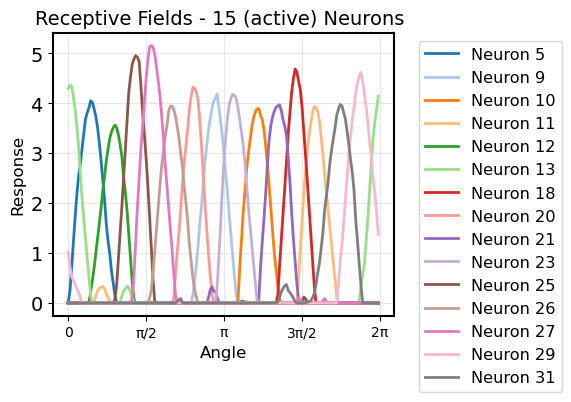

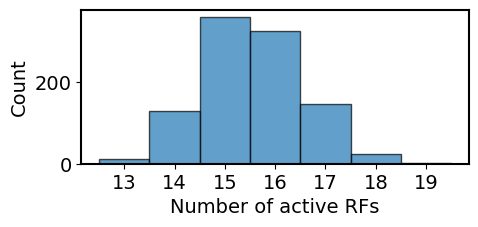

In [7]:
desired_num_active_neurons = 15 # This can vary, e.g. 14, 15, 16, 17
stim_alpha = 25 # degree, this correspons to $\alpha$ in the paper, and is the angle of the trial stimulus for which we plot the RSM off-diagonal entries.

from sklearn.metrics import pairwise
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
# Prepare data (same scaling as training)
imgs_flat = imgs.reshape(imgs.shape[0], -1).astype(np.float32)
scaler = MinMaxScaler()
imgs_scaled = scaler.fit_transform(imgs_flat)
imgs_tensor = torch.FloatTensor(imgs_scaled)
    
# Run baseline model
ALL_PHIs = []; num_active_neurons_manual = []
all_RSMs = []; all_RSMs_cosine = []; model_losses = []
LOAD_FROM_FILE = True
runs = range(numruns)
xc = 0
for run in runs:
    # Run or LOAD base model
    if LOAD_FROM_FILE:
        model = TwoLayerAutoencoder(input_dim=imgs.shape[1]*imgs.shape[2], hidden_dim=params['hidden_dim'], use_bias=params['use_bias'])
        modelfile = os.path.join(models_folder, f'model_run{run}.pth')
        model.load_state_dict(torch.load(modelfile))
    else:
        model, hidden_reps, phases, colors, scaler = run_model(model = None, imgs=imgs, params=params)
    hidden_activations0, angles = compute_receptive_fields_from_imgs(model, imgs)

    # For each model calcualte the loss
    model.eval()

    # Get reconstruction
    with torch.no_grad():
        reconstructed, _ = model(imgs_tensor)
        reconstructed = reconstructed.cpu().numpy()
    
    # Calculate MSE loss
    loss = mean_squared_error(imgs_scaled, reconstructed)
    model_losses.append(loss)

    rfmax = np.max(hidden_activations0, axis=1)
    freqs1, mags1, phases1 = compute_spectra(rfmax, fs=180/np.pi)
    expected_peak = desired_num_active_neurons/np.pi  # in rad/sample
    idx_peak = np.argmin(np.abs(freqs1 - expected_peak))
    rf_phase = phases1[:,idx_peak][0]
 
    max_phi_shift = 180.0
    phi_shifts = angles[0:np.where(angles>=max_phi_shift*np.pi/180)[0][0]]*180/np.pi  # in degrees

    
    # Find the peaks for base model to set the gauge
    idx_active_neurons = np.where(np.max(hidden_activations0,axis=0)>1)[0]
  
    shift_index = int(0.5*(rf_phase/np.pi)*(180/desired_num_active_neurons)) 
    #shift_index =0
    #print(shift_index)
    hidden_activations1 = np.roll(hidden_activations0, shift_index, axis=0)

    # optional: plot some RFs
    if run<100:
        idx_active_neurons = np.where(np.max(hidden_activations1,axis=0)>1)[0]
        if len(idx_active_neurons)==desired_num_active_neurons:
            if xc==0:
                xc = xc +1
                savefigfile = os.path.join(fig_folder,'autoencoder_japanese32_rfs_numneuron'+str(desired_num_active_neurons)+'.svg')
                plot_neuron_rfs_simple(hidden_activations1, angles, neuron_indices=list(idx_active_neurons), savefigfile = savefigfile, figsize = (6,4))
                run_save = run
    RSM_over_time = []; RSMs_cosine_over_time = []
    for ie, phi in enumerate(phi_shifts):
        # shift the phi
        phi_shift = phi_shifts[ie]
        hidden_activations = np.roll(hidden_activations1, int(phi_shift*N/360), axis=0)
        
        RSM = hidden_activations @ hidden_activations.T
        RSM_cosine = pairwise.cosine_similarity(hidden_activations)

        RSM_over_time.append(RSM); RSMs_cosine_over_time.append(RSM_cosine)

        idx_active_neurons = np.where(np.max(hidden_activations,axis=0)>1)[0]
        
    all_RSMs.append(RSM_over_time)
    all_RSMs_cosine.append(RSMs_cosine_over_time)    

    num_active_neurons_manual.append(len(idx_active_neurons))
  
    Shift = 0

    ALL_PHIs.append(phi_shifts-Shift)

all_RSMs = np.array(all_RSMs); all_RSMs_cosine = np.array(all_RSMs_cosine); model_losses = np.array(model_losses)


idx_alpha = np.argmin(np.abs(angles*180/np.pi - stim_alpha))
ALL_PHIs = np.array(ALL_PHIs)
num_active_neurons_manual = np.array(num_active_neurons_manual)


# plot distribution of number of active neurons across runs
plt.figure( figsize=(5, 2))
bins = np.arange(np.array(num_active_neurons_manual).min() - 0.5, np.array(num_active_neurons_manual).max() + 1.5, 1)  # edges between integers
plt.hist(num_active_neurons_manual, bins=bins, edgecolor='black', color='tab:blue', alpha=0.7)
plt.xlabel('Number of active RFs')
plt.ylabel('Count')
plt.xticks(range(np.array(num_active_neurons_manual).min(), np.array(num_active_neurons_manual).max() + 1))  # show each integer on x-axis
plt.savefig(fig_folder + '/num_active_neurons_distribution_japanese32.svg', dpi=300)



# Infer $\varphi$ for each run

/var/folders/s4/9xqxhjy92z1f9yr5v7h28_3r0000gn/T/ipykernel_6464/1073706531.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  shift_index_display = int(0.5*(rf_phase_display/np.pi)*(180/desired_num_active_neurons))


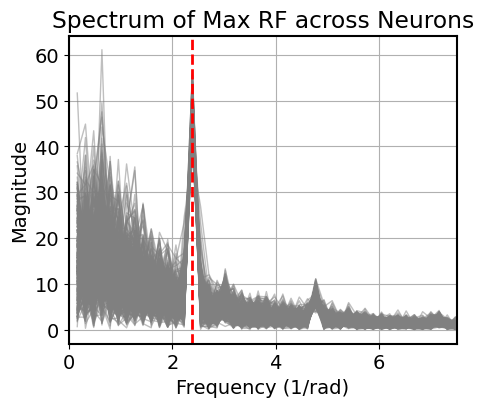

In [8]:
num_active_neurons_manual = []
all_RSMs0 = []; all_RSMs_cosine0 = []
all_rfmax = []

LOAD_FROM_FILE = True
runs = range(numruns)
for run in runs:
    # Run or LOAD base model
    if LOAD_FROM_FILE:
        model = TwoLayerAutoencoder(input_dim=imgs.shape[1]*imgs.shape[2], hidden_dim=params['hidden_dim'], use_bias=params['use_bias'])
        modelfile = os.path.join(models_folder, f'model_run{run}.pth')
        model.load_state_dict(torch.load(modelfile))
    else:
        model, hidden_reps, phases, colors, scaler = run_model(model = None, imgs=imgs, params=params)
    hidden_activations0, angles = compute_receptive_fields_from_imgs(model, imgs)
    rfmax = np.max(hidden_activations0, axis=1)
    all_rfmax.append(rfmax)

    RSM = hidden_activations0 @ hidden_activations0.T
    RSM_cosine = pairwise.cosine_similarity(hidden_activations0)

    all_RSMs0.append(RSM)
    all_RSMs_cosine0.append(RSM_cosine)

    idx_active_neurons = np.where(np.max(hidden_activations0,axis=0)>1)[0]

    # plot rf
    if run<15:
        idx_active_neurons = np.where(np.max(hidden_activations0,axis=0)>1)[0]
        if len(idx_active_neurons)==desired_num_active_neurons:
            #plot_neuron_rfs_simple(hidden_activations0, angles, neuron_indices=list(idx_active_neurons))
            rfmax = np.max(hidden_activations0, axis=1)
            
            #plt.plot(angles, rfmax, linewidth=2, label='Mean RF')
  
    num_active_neurons_manual.append(len(idx_active_neurons))
all_rfmax = np.array(all_rfmax)
num_active_neurons_manual = np.array(num_active_neurons_manual)
all_RSMs0 = np.array(all_RSMs0)
all_RSMs_cosine0 = np.array(all_RSMs_cosine0)

idxruns = np.where(num_active_neurons_manual==desired_num_active_neurons)[0]
freqs0, mags0, phases0 = compute_spectra(all_rfmax[idxruns,:], fs=180/(2*np.pi))
expected_peak = desired_num_active_neurons/(2*np.pi)  # in rad/sample
idx_peak0 = np.argmin(np.abs(freqs0 - expected_peak))
rf_phases = phases0[:,idx_peak0]


idx_run_save = np.where(idxruns == run_save)[0]
rf_phase_display = rf_phases[idx_run_save]
shift_index_display = int(0.5*(rf_phase_display/np.pi)*(180/desired_num_active_neurons)) 
rf_max_display = all_rfmax[run_save,:]
rf_max_display_shifted = np.roll(rf_max_display, shift_index_display, axis=0)



plt.figure(figsize=(5, 4))
plt.plot(freqs0[1:], mags0[0:,1:].T, alpha = 0.5, linewidth=1, label='RF Max Spectrum', color = 'gray')
plt.axvline(x=expected_peak, color='r', linestyle='--', label='Expected freq = ' + str(expected_peak))
plt.xlabel('Frequency (1/rad)')
plt.ylabel('Magnitude')
plt.title('Spectrum of Max RF across Neurons')
plt.grid(True)
plt.xlim(0,7.5)
plt.savefig(os.path.join(fig_folder,f'autoencoder_japanese32_rfmax_spectrum_{desired_num_active_neurons}active_neurons.svg'), dpi=300)


# Show relationship between RF-inferred $\varphi$ and RSM

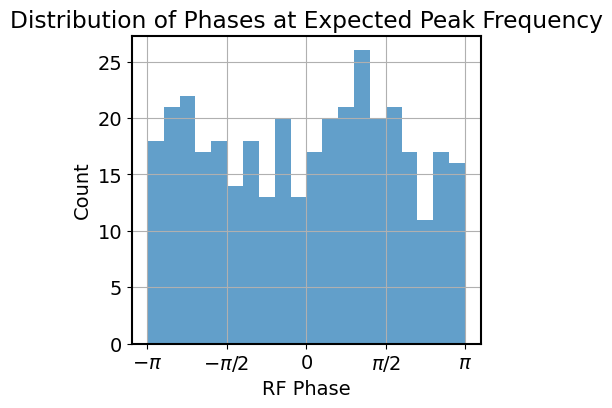

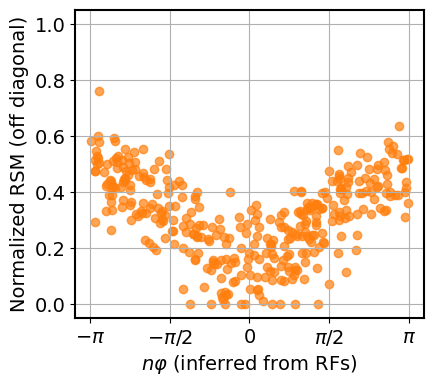

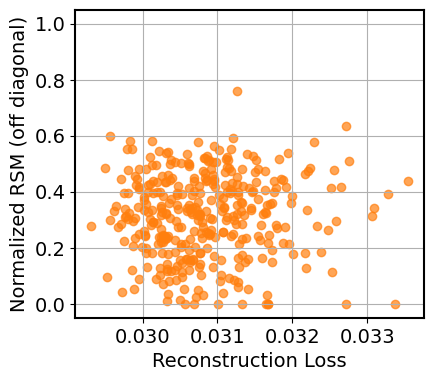

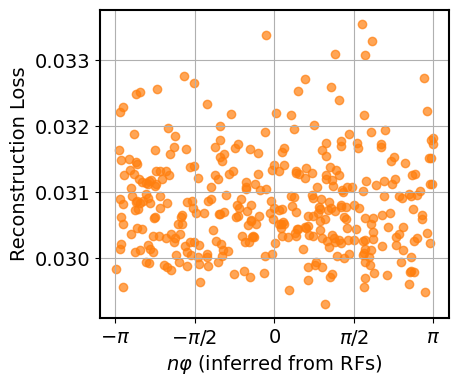

Correlation between |RF phases| and RSM cosine values: 0.759, p-value: 1.020e-68
Correlation between Reconstruction Loss and RSM cosine values: 0.031, p-value: 5.558e-01
Correlation between RF phases and Reconstruction Loss: 0.022, p-value: 6.732e-01


In [19]:
# histogram of phases_at_peak
plt.figure(figsize=(4.5, 4))
plt.hist(rf_phases, bins=20, color='tab:blue', alpha=0.7)
phi_labels = np.linspace(-np.pi, np.pi, 5)
plt.xticks(phi_labels, [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
plt.xlabel('RF Phase')
plt.ylabel('Count')
plt.title('Distribution of Phases at Expected Peak Frequency')
plt.grid(True)
plt.savefig(os.path.join(fig_folder,f'autoencoder_japanese32_rsm_cosine_rfphase_hist_{desired_num_active_neurons}active_neurons.svg'), dpi=300)
plt.show()


stim_alpha = 25 # degree
idx_alpha = np.argmin(np.abs(angles*180/np.pi - stim_alpha))

# plot scatter plot of rsm cosine off-diagonal vs rf phase at peak
plt.figure(figsize=(4.5, 4))
plt.scatter(rf_phases, all_RSMs_cosine0[idxruns, 0, idx_alpha], color='tab:orange', alpha=0.7)
phi_labels = np.linspace(-np.pi, np.pi, 5)
plt.xticks(phi_labels, [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
plt.xlabel(r'$n\varphi$ (inferred from RFs)')
plt.ylabel('Normalized RSM (off diagonal)')
#plt.title('Scatter Plot of RSM Cosine vs RF Phase at Peak')
plt.grid(True)
plt.ylim(-0.05, 1.05)
plt.savefig(os.path.join(fig_folder,f'autoencoder_japanese32_rsm_cosine_vs_rfphase_scatter_{desired_num_active_neurons}active_neurons.svg'), dpi=300)
plt.show()


# Show a couple of examples here
idx1_ = np.argmin(np.abs(rf_phases - (-2*np.pi/3))); idx1 = idxruns[idx1_]
idx2_ = np.argmin(np.abs(rf_phases - (0))); idx2 = idxruns[idx2_]
idx3_ = np.argmin(np.abs(rf_phases - (2*np.pi/3))); idx3 = idxruns[idx3_]

# plt.scatter(rf_phases[idx1_], all_RSMs_cosine0[idx1, 0, idx_alpha], color='black', s=50, label='Example 1', marker='o', facecolors='none')
# plt.scatter(rf_phases[idx2_], all_RSMs_cosine0[idx2, 0, idx_alpha], color='black', s=50, label='Example 2', marker='o', facecolors='none')
# plt.scatter(rf_phases[idx3_], all_RSMs_cosine0[idx3, 0, idx_alpha], color='black', s=50, label='Example 3', marker='o', facecolors='none')

# plot scatter plot of rsm cosine vs model lossmodel_losses[idxruns]
plt.figure(figsize=(4.5, 4))
plt.scatter(model_losses[idxruns], all_RSMs_cosine0[idxruns, 0, idx_alpha], color='tab:orange', alpha=0.7)
plt.xlabel('Reconstruction Loss')
plt.ylabel('Normalized RSM (off diagonal)')
#plt.title('Scatter Plot of RSM Cosine vs Loss')
plt.grid(True)
plt.ylim(-0.05, 1.05)
plt.savefig(os.path.join(fig_folder,f'autoencoder_japanese32_rsm_cosine_vs_loss_scatter_{desired_num_active_neurons}active_neurons.svg'), dpi=300)
plt.show()


# Do a scatter of recon loss vs rf phase
plt.figure(figsize=(4.5, 4))
plt.scatter(rf_phases, model_losses[idxruns], color='tab:orange', alpha=0.7)
phi_labels = np.linspace(-np.pi, np.pi, 5)
plt.xticks(phi_labels, [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
plt.xlabel(r'$n\varphi$ (inferred from RFs)')
plt.ylabel('Reconstruction Loss')
#plt.title('Scatter Plot of Loss vs RF Phase')
plt.grid(True)
plt.savefig(os.path.join(fig_folder,f'autoencoder_japanese32_loss_vs_rfphase_scatter_{desired_num_active_neurons}active_neurons.svg'), dpi=300)
plt.show()  

# Perform a correlation analysis between the all_RSMs_cosine0[idxruns, 0, idx_alpha] and rf_phases and report p-value
from scipy.stats import pearsonr
correlation, p_value = pearsonr(np.abs(rf_phases), all_RSMs_cosine0[idxruns, 0, idx_alpha])
print(f"Correlation between |RF phases| and RSM cosine values: {correlation:.3f}, p-value: {p_value:.3e}")

# Perform a correlation analysis between the all_RSMs_cosine0[idxruns, 0, idx_alpha] and model_losses[idxruns] and report p-value
correlation_loss_rsm, p_value_loss_rsm = pearsonr(model_losses[idxruns], all_RSMs_cosine0[idxruns, 0, idx_alpha])
print(f"Correlation between Reconstruction Loss and RSM cosine values: {correlation_loss_rsm:.3f}, p-value: {p_value_loss_rsm:.3e}")

# Perform a correlation analysis between the model_losses[idxruns] and rf_phases and report p-value
correlation_loss, p_value_loss = pearsonr(np.abs(rf_phases), model_losses[idxruns])
print(f"Correlation between RF phases and Reconstruction Loss: {correlation_loss:.3f}, p-value: {p_value_loss:.3e}")

# CKA Analysis on the RSM matrices
Setup

In [10]:
import numpy as np

def _center_gram(K):
    """Center an (n, n) Gram matrix."""
    n = K.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ K @ H

def kernel_cka(K, L, centered=True):
    """
    Kernel CKA between Gram matrices K and L (both n x n).

    Parameters
    ----------
    K, L : (n, n) arrays
        Kernel / Gram matrices.
    centered : bool
        If True  -> standard (centered) CKA.
        If False -> non-centered CKA (no kernel centering).

    Returns
    -------
    cka_value : float
        Similarity in [0, 1] (for PSD kernels).
    """
    if centered:
        K = _center_gram(K)
        L = _center_gram(L)

    num = np.sum(K * L)                    # Frobenius inner product = trace(K^T L)
    denom = np.sqrt(np.sum(K * K) * np.sum(L * L))
    return num / denom


def cka(X, Y, kernel_fn=None, centered=True):
    """
    Compute kernel CKA between X and Y.

    Parameters
    ----------
    X, Y :
        - If kernel_fn is None: assumed to be Gram matrices (n, n).
        - If kernel_fn is not None: data matrices (n, d_x) and (n, d_y),
          and kernel_fn is used to build Gram matrices.
    kernel_fn : callable or None
        Function mapping data to kernels: K = kernel_fn(Z), where K is (n, n).
    centered : bool
        If True  -> standard (centered) CKA.
        If False -> non-centered CKA.

    Returns
    -------
    cka_value : float
    """
    if kernel_fn is None:
        K, L = X, Y
    else:
        K = kernel_fn(X)
        L = kernel_fn(Y)
    return kernel_cka(K, L, centered=centered)

# Calculate CKA for multiple runs

In [11]:
# Arrange set of RSMs for the selected runs
stim_alpha = 2 # degree
stim_alpha = np.max([360/len(angles), stim_alpha])
idx_alpha = np.argmin(np.abs(angles*180/np.pi - stim_alpha))

alphas_for_RSM = np.round(np.arange(0, 360-stim_alpha, stim_alpha))
idx_alphas_for_RSM = [np.argmin(np.abs(angles*180/np.pi - alpha)) for alpha in alphas_for_RSM]
all_RSMs0_reduced = np.asarray([all_RSMs0[idxrun][np.ix_(idx_alphas_for_RSM, idx_alphas_for_RSM)] for idxrun in idxruns])
all_RSMs_cosine0_reduced = np.asarray([all_RSMs_cosine0[idxrun][np.ix_(idx_alphas_for_RSM, idx_alphas_for_RSM)] for idxrun in idxruns])
print('Number of runs with ' + str(desired_num_active_neurons) + ' active neurons: ' + str(len(idxruns)))


# Calculate CKA between all RSM pairs as well as RSM cosine pairs. Create a matrix of them.
#  Then sort them based on the rfphase and plot them as a heatmap. There will be 4 matrices total
cka_matrix_rsm = np.zeros((len(idxruns), len(idxruns)))
cka_matrix_rsm_cosine = np.zeros((len(idxruns), len(idxruns)))
for i, idx_i in enumerate(idxruns):
    for j, idx_j in enumerate(idxruns):
        if j > i:
            continue
        cka_matrix_rsm[i, j] = cka(all_RSMs0_reduced[i], all_RSMs0_reduced[j]); cka_matrix_rsm[j, i] = cka_matrix_rsm[i, j]
        cka_matrix_rsm_cosine[i, j] = cka(all_RSMs_cosine0_reduced[i], all_RSMs_cosine0_reduced[j]); cka_matrix_rsm_cosine[j, i] = cka_matrix_rsm_cosine[i, j]

# Sort the matrices based on rfphase
sorted_indices = np.argsort(rf_phases)
cka_matrix_rsm_sorted = cka_matrix_rsm[sorted_indices][:, sorted_indices]
cka_matrix_rsm_cosine_sorted = cka_matrix_rsm_cosine[sorted_indices][:, sorted_indices]




Number of runs with 15 active neurons: 360


# Plot CKA results

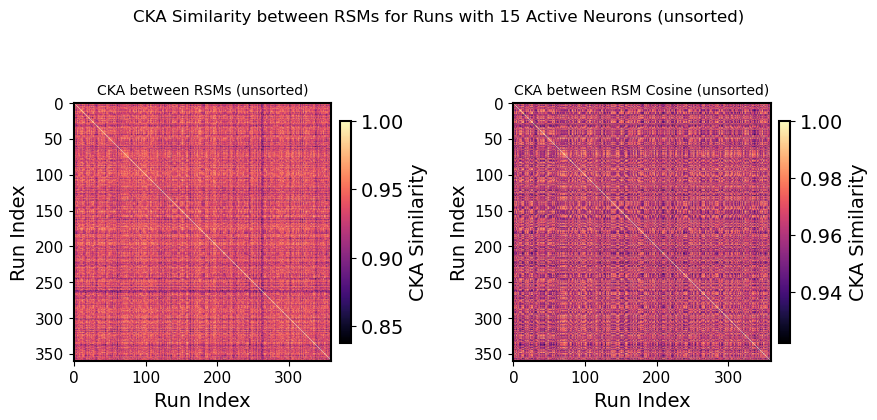

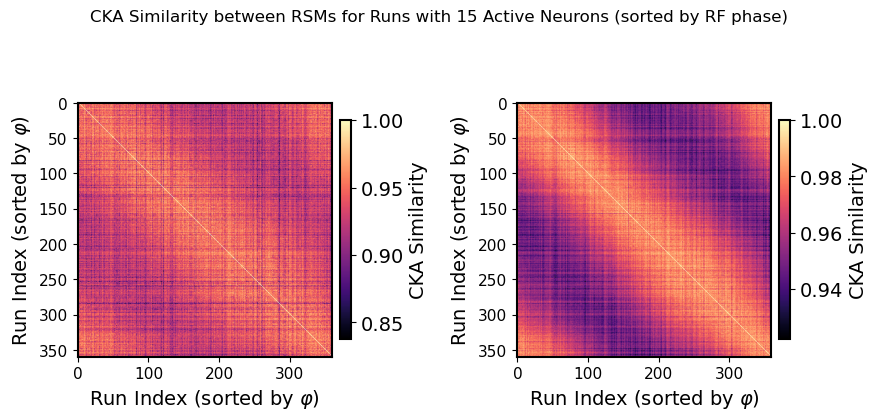

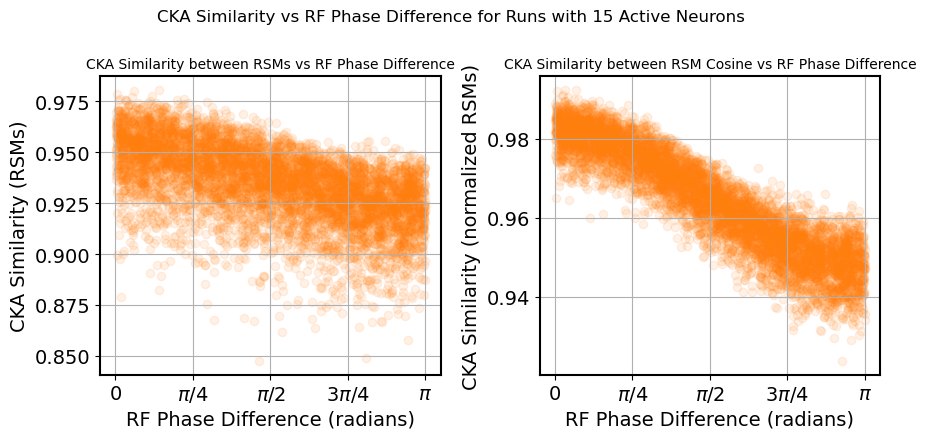

Correlation between RF phase difference and CKA similarity (RSMs): -0.562, p-value: 0.000e+00
Correlation between RF phase difference and CKA similarity (RSM Cosine): -0.909, p-value: 0.000e+00


In [20]:
# plot also the raw CKA matrices without sorting
fig, axs = plt.subplots(1, 2, figsize=(9, 4.5))
im0 = axs[0].imshow(cka_matrix_rsm, cmap = 'magma', interpolation=None)
axs[0].set_title('CKA between RSMs (unsorted)', fontsize=10)
axs[0].set_xlabel('Run Index')
axs[0].set_ylabel('Run Index')
axs[0].tick_params(axis='both', which='major', labelsize=11)
fig.colorbar(im0, ax=axs[0], fraction=0.04, pad=0.03, label='CKA Similarity')
im1 = axs[1].imshow(cka_matrix_rsm_cosine, cmap = 'magma', interpolation=None)
axs[1].set_title('CKA between RSM Cosine (unsorted)', fontsize=10)
axs[1].set_xlabel('Run Index')
axs[1].set_ylabel('Run Index')
axs[1].tick_params(axis='both', which='major', labelsize=11)
fig.colorbar(im1, ax=axs[1], fraction=0.04, pad=0.03, label='CKA Similarity')
plt.suptitle(f'CKA Similarity between RSMs for Runs with {desired_num_active_neurons} Active Neurons (unsorted)', fontsize=12)
fig.tight_layout()
plt.show()

# Plot the sorted CKA matrices as heatmaps
fig, axs = plt.subplots(1, 2, figsize=(9, 4.5))
im0 = axs[0].imshow(cka_matrix_rsm_sorted, cmap = 'magma', interpolation=None)
#axs[0].set_title('CKA between RSMs (sorted by RF phase)', fontsize=10)
axs[0].set_xlabel('Run Index (sorted by '+ r'$\varphi$)')
axs[0].set_ylabel('Run Index (sorted by '+ r'$\varphi$)')
# change x and y ticklabels fontsize
axs[0].tick_params(axis='both', which='major', labelsize=11)

fig.colorbar(im0, ax=axs[0], fraction=0.04, pad=0.03, label='CKA Similarity')
im1 = axs[1].imshow(cka_matrix_rsm_cosine_sorted, cmap='magma', interpolation=None)
#axs[1].set_title('CKA between RSM Cosine (sorted by RF phase)', fontsize=10)
axs[1].set_xlabel('Run Index (sorted by '+ r'$\varphi$)')
axs[1].set_ylabel('Run Index (sorted by '+ r'$\varphi$)')
axs[1].tick_params(axis='both', which='major', labelsize=11)
fig.colorbar(im1, ax=axs[1], fraction=0.04, pad=0.03, label='CKA Similarity')
plt.suptitle(f'CKA Similarity between RSMs for Runs with {desired_num_active_neurons} Active Neurons (sorted by RF phase)', fontsize=12)
fig.tight_layout()
plt.savefig(os.path.join(fig_folder,f'autoencoder_japanese32_cka_matrices_sorted_by_rfphase_{desired_num_active_neurons}active_neurons.svg'), dpi=300)
plt.show()

# For all pairs of the CKA matrices, plot them as a function RF phase difference. Generate two scatter plots
rf_phase_diff = np.abs(rf_phases[:, None] - rf_phases[None, :])
rf_phase_diff = np.minimum(rf_phase_diff, 2 * np.pi - rf_phase_diff)
# Flatten the upper triangle of the matrices for plotting
triu_indices = np.triu_indices_from(cka_matrix_rsm, k=1)
cka_values_rsm = cka_matrix_rsm[triu_indices]
cka_values_rsm_cosine = cka_matrix_rsm_cosine[triu_indices]
rf_phase_diff_flat = rf_phase_diff[triu_indices]

steps = 10 # plot only a subset of points for better visualization
# plot two at two subplots 1x 2
fig, axs = plt.subplots(1, 2, figsize=(9, 4.5))
axs[0].scatter(rf_phase_diff_flat[::steps], cka_values_rsm[::steps], color='tab:orange', alpha=0.1)
axs[0].set_xlabel('RF Phase Difference (radians)')
axs[0].set_ylabel('CKA Similarity (RSMs)')
axs[0].set_title('CKA Similarity between RSMs vs RF Phase Difference', fontsize=10)
axs[0].grid(True)

phi_labels = np.linspace(0, np.pi, 5)
axs[0].set_xticks(phi_labels)
axs[0].set_xticklabels([r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
axs[1].scatter(rf_phase_diff_flat[::steps], cka_values_rsm_cosine[::steps], color='tab:orange', alpha=0.1)
axs[1].set_xlabel('RF Phase Difference (radians)')
axs[1].set_ylabel('CKA Similarity (normalized RSMs)')
axs[1].set_title('CKA Similarity between RSM Cosine vs RF Phase Difference', fontsize=10)
axs[1].grid(True)

axs[1].set_xticks(phi_labels)
axs[1].set_xticklabels([r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
plt.suptitle(f'CKA Similarity vs RF Phase Difference for Runs with {desired_num_active_neurons} Active Neurons', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(fig_folder,f'autoencoder_japanese32_cka_vs_rfphase_scatter_{desired_num_active_neurons}active_neurons.svg'), dpi=300)
plt.show()

# Perform correlation analysis between rf_phase_diff_flat and cka_values_rsm, as well as cka_values_rsm_cosine, and report the correlation coefficient and p-value for both
correlation_rsm, p_value_rsm = pearsonr(rf_phase_diff_flat, cka_values_rsm)
correlation_rsm_cosine, p_value_rsm_cosine = pearsonr(rf_phase_diff_flat, cka_values_rsm_cosine)
print(f"Correlation between RF phase difference and CKA similarity (RSMs): {correlation_rsm:.3f}, p-value: {p_value_rsm:.3e}")
print(f"Correlation between RF phase difference and CKA similarity (RSM Cosine): {correlation_rsm_cosine:.3f}, p-value: {p_value_rsm_cosine:.3e}")
